# Objetivo: Identificar quais características e hábitos dos atletas de academia possuem maior associação com um menor percentual de gordura (BF).

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

path = '/content/gym_members_exercise_tracking.csv'

df = pd.read_csv(path)
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### Sobre o dataset

Este conjunto de dados oferece uma visão detalhada das rotinas de exercícios, atributos físicos e métricas de condicionamento físico de membros de academia. Ele contém 973 amostras de dados de treinos, incluindo indicadores-chave de desempenho, como frequência cardíaca, calorias queimadas e duração do treino. Cada registro também inclui dados demográficos e níveis de experiência, permitindo uma análise abrangente de padrões de atividade física, progressão dos atletas e tendências de saúde.

Variáveis:

- `Age`: Idade do membro da academia.

- `Gender`: Gênero do membro da academia (Masculino ou Feminino).

- `Weight (kg)`: Peso do membro em quilogramas.

- `Height (m)`: Altura do membro em metros.

- `Max_BPM`: Frequência cardíaca máxima (batimentos por minuto) durante as sessões de treino.

- `Avg_BPM`: Frequência cardíaca média durante as sessões de treino.

- `Resting_BPM`: Frequência cardíaca em repouso antes do treino.

- `Session_Duration (hours)`: Duração de cada sessão de treino em horas.

- `Calories_Burned`: Total de calorias queimadas durante cada sessão.

- `Workout_Type`: Tipo de treino realizado (ex: Cardio, Força/Musculação, Yoga, HIIT).

- `Fat_Percentage`: Percentual de gordura corporal do membro (BF).

- `Water_Intake (liters)`: Consumo diário de água durante os treinos (em litros).

- `Workout_Frequency (days/week)`: Número de sessões de treino por semana.

- `Experience_Level`: Nível de experiência no treino, variando de iniciante (1) a especialista/avançado (3).

- `BMI`: Índice de Massa Corporal, calculado a partir da altura e do peso.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

# Análise dos dados

## Matriz de Correlação

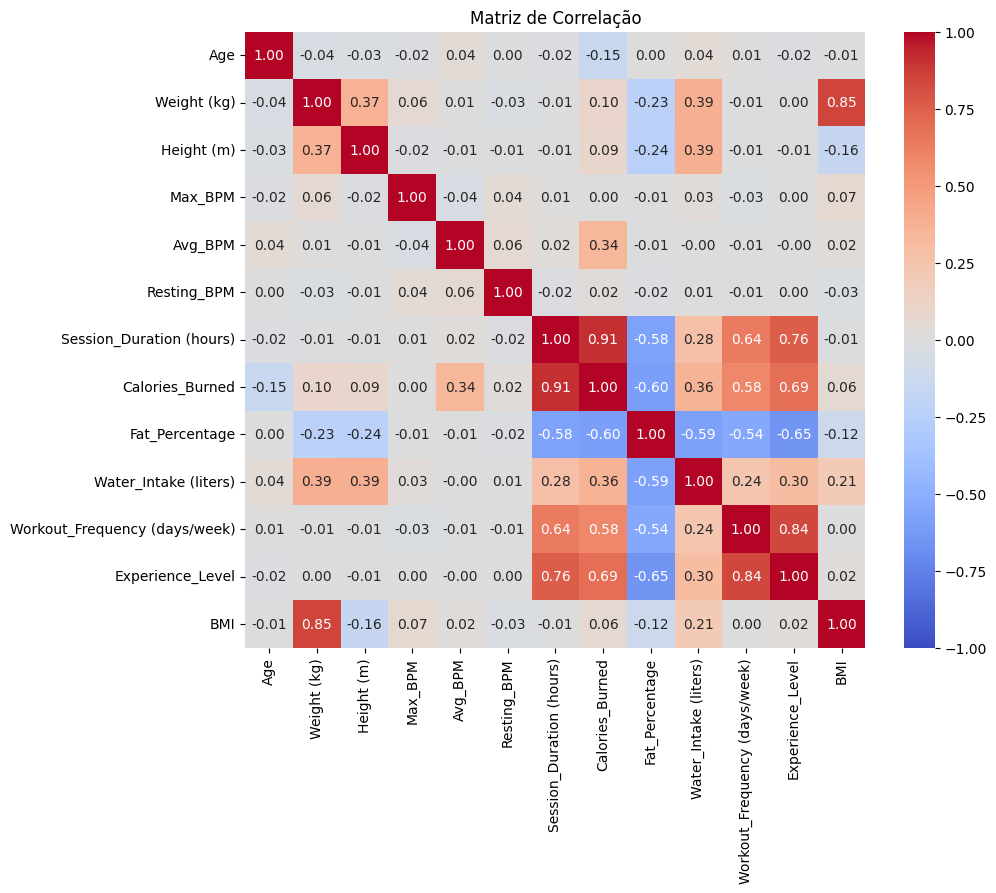

In [9]:
# Selecionando apenas as colunas numéricas para o heatmap
colunas_numericas = df.select_dtypes(include=['float64', 'int64'])

# Calculando a matriz de correlação
matriz_corr = colunas_numericas.corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

Analisando a coluna da variável alvo `Fat_Percentage` (Percentual de Gordura), extraímos os seguintes direcionamentos para a nossa análise exploratória:

1. **O Bloco de Hábitos e Consistência (Associações Fortes):**
   * O nível de experiência (`Experience_Level`) lidera a associação negativa com o BF (**-0.65**).
   * Logo em seguida, o gasto calórico (`Calories_Burned` com **-0.60**) e mais três variáveis comportamentais apresentam um impacto semelhante: a ingestão de água (`Water_Intake` com **-0.59**), a duração da sessão (`Session_Duration` com **-0.58**) e a frequência semanal (`Workout_Frequency` com **-0.54**).
   * Estatisticamente, isso demonstra que o BF reduzido não está ligado a um fator isolado, mas sim a um conjunto de hábitos combinados (treinos mais longos, maior frequência e hidratação rigorosa).

2. **A Desmistificação dos Batimentos Cardíacos e Idade (Correlação Nula):**
   * As variáveis `Avg_BPM` (**-0.01**), `Max_BPM` (**-0.01**) e `Age` (**0.00**) possuem correlação linear nula com o percentual de gordura.
   * Isso quebra o senso comum de que treinar com batimentos mais altos ou ser mais jovem dita diretamente um BF menor. O esforço cardíaco momentâneo reflete apenas o estresse do exercício na hora, enquanto a composição corporal responde ao volume e à consistência a longo prazo.

## Análise Univariada

### Variáveis categóricas

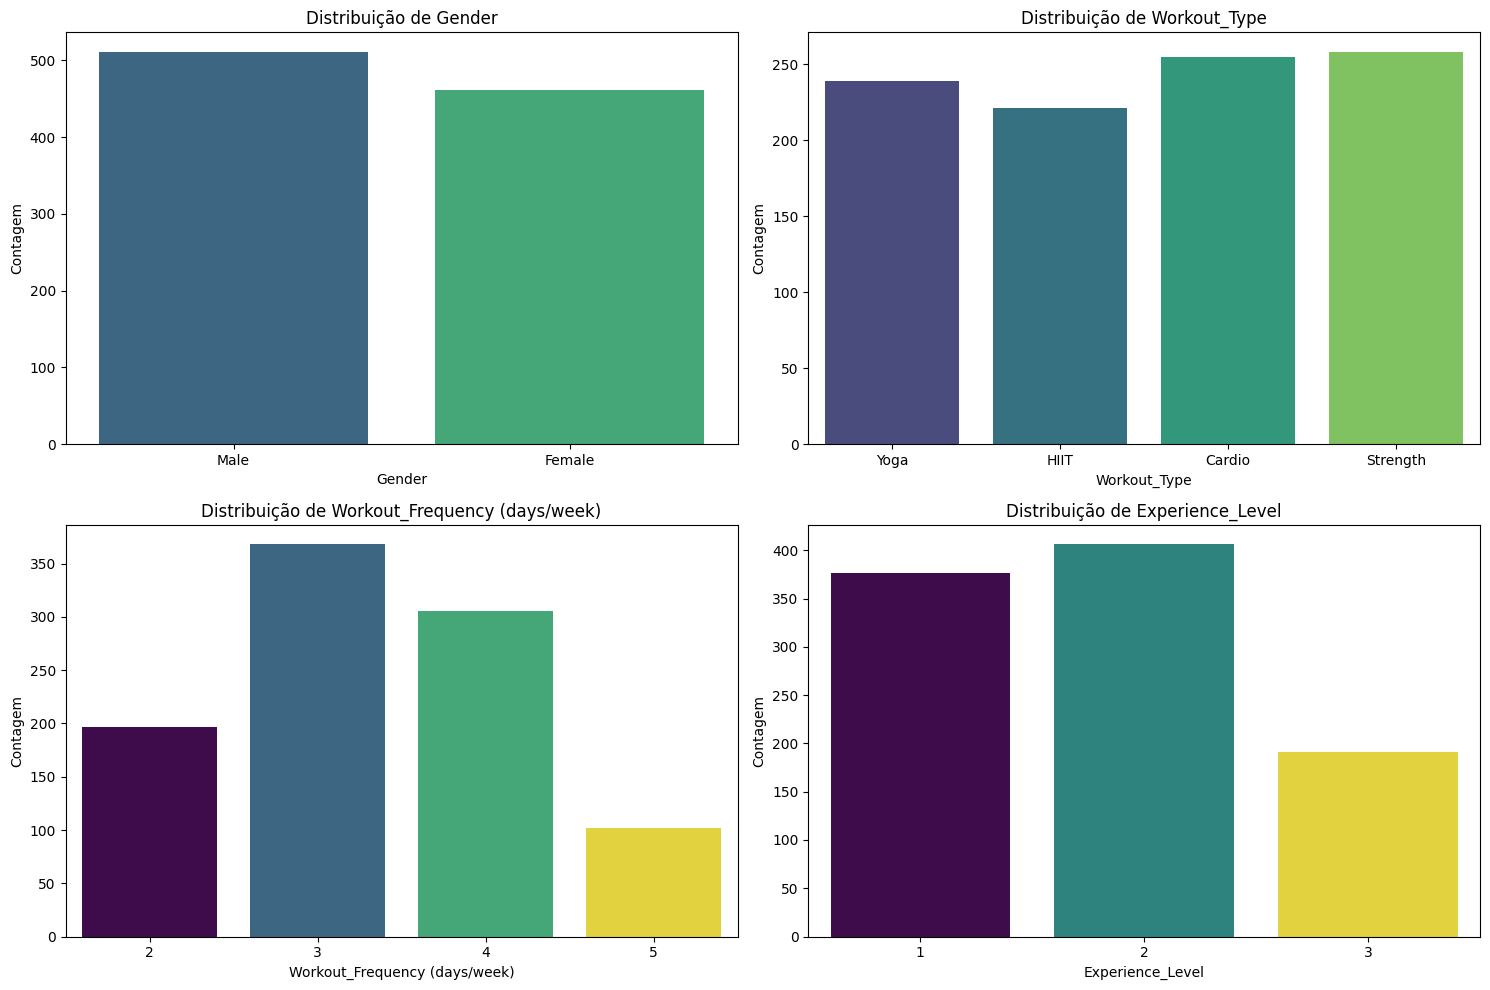

In [47]:
cols_categoricas = ['Gender', 'Workout_Type', 'Workout_Frequency (days/week)', 'Experience_Level']

n_cols_grid = 2
n_rows_grid = 2

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', hue=col, legend=False)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Contagem')
    if col == 'Age':
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Variáveis contínuas

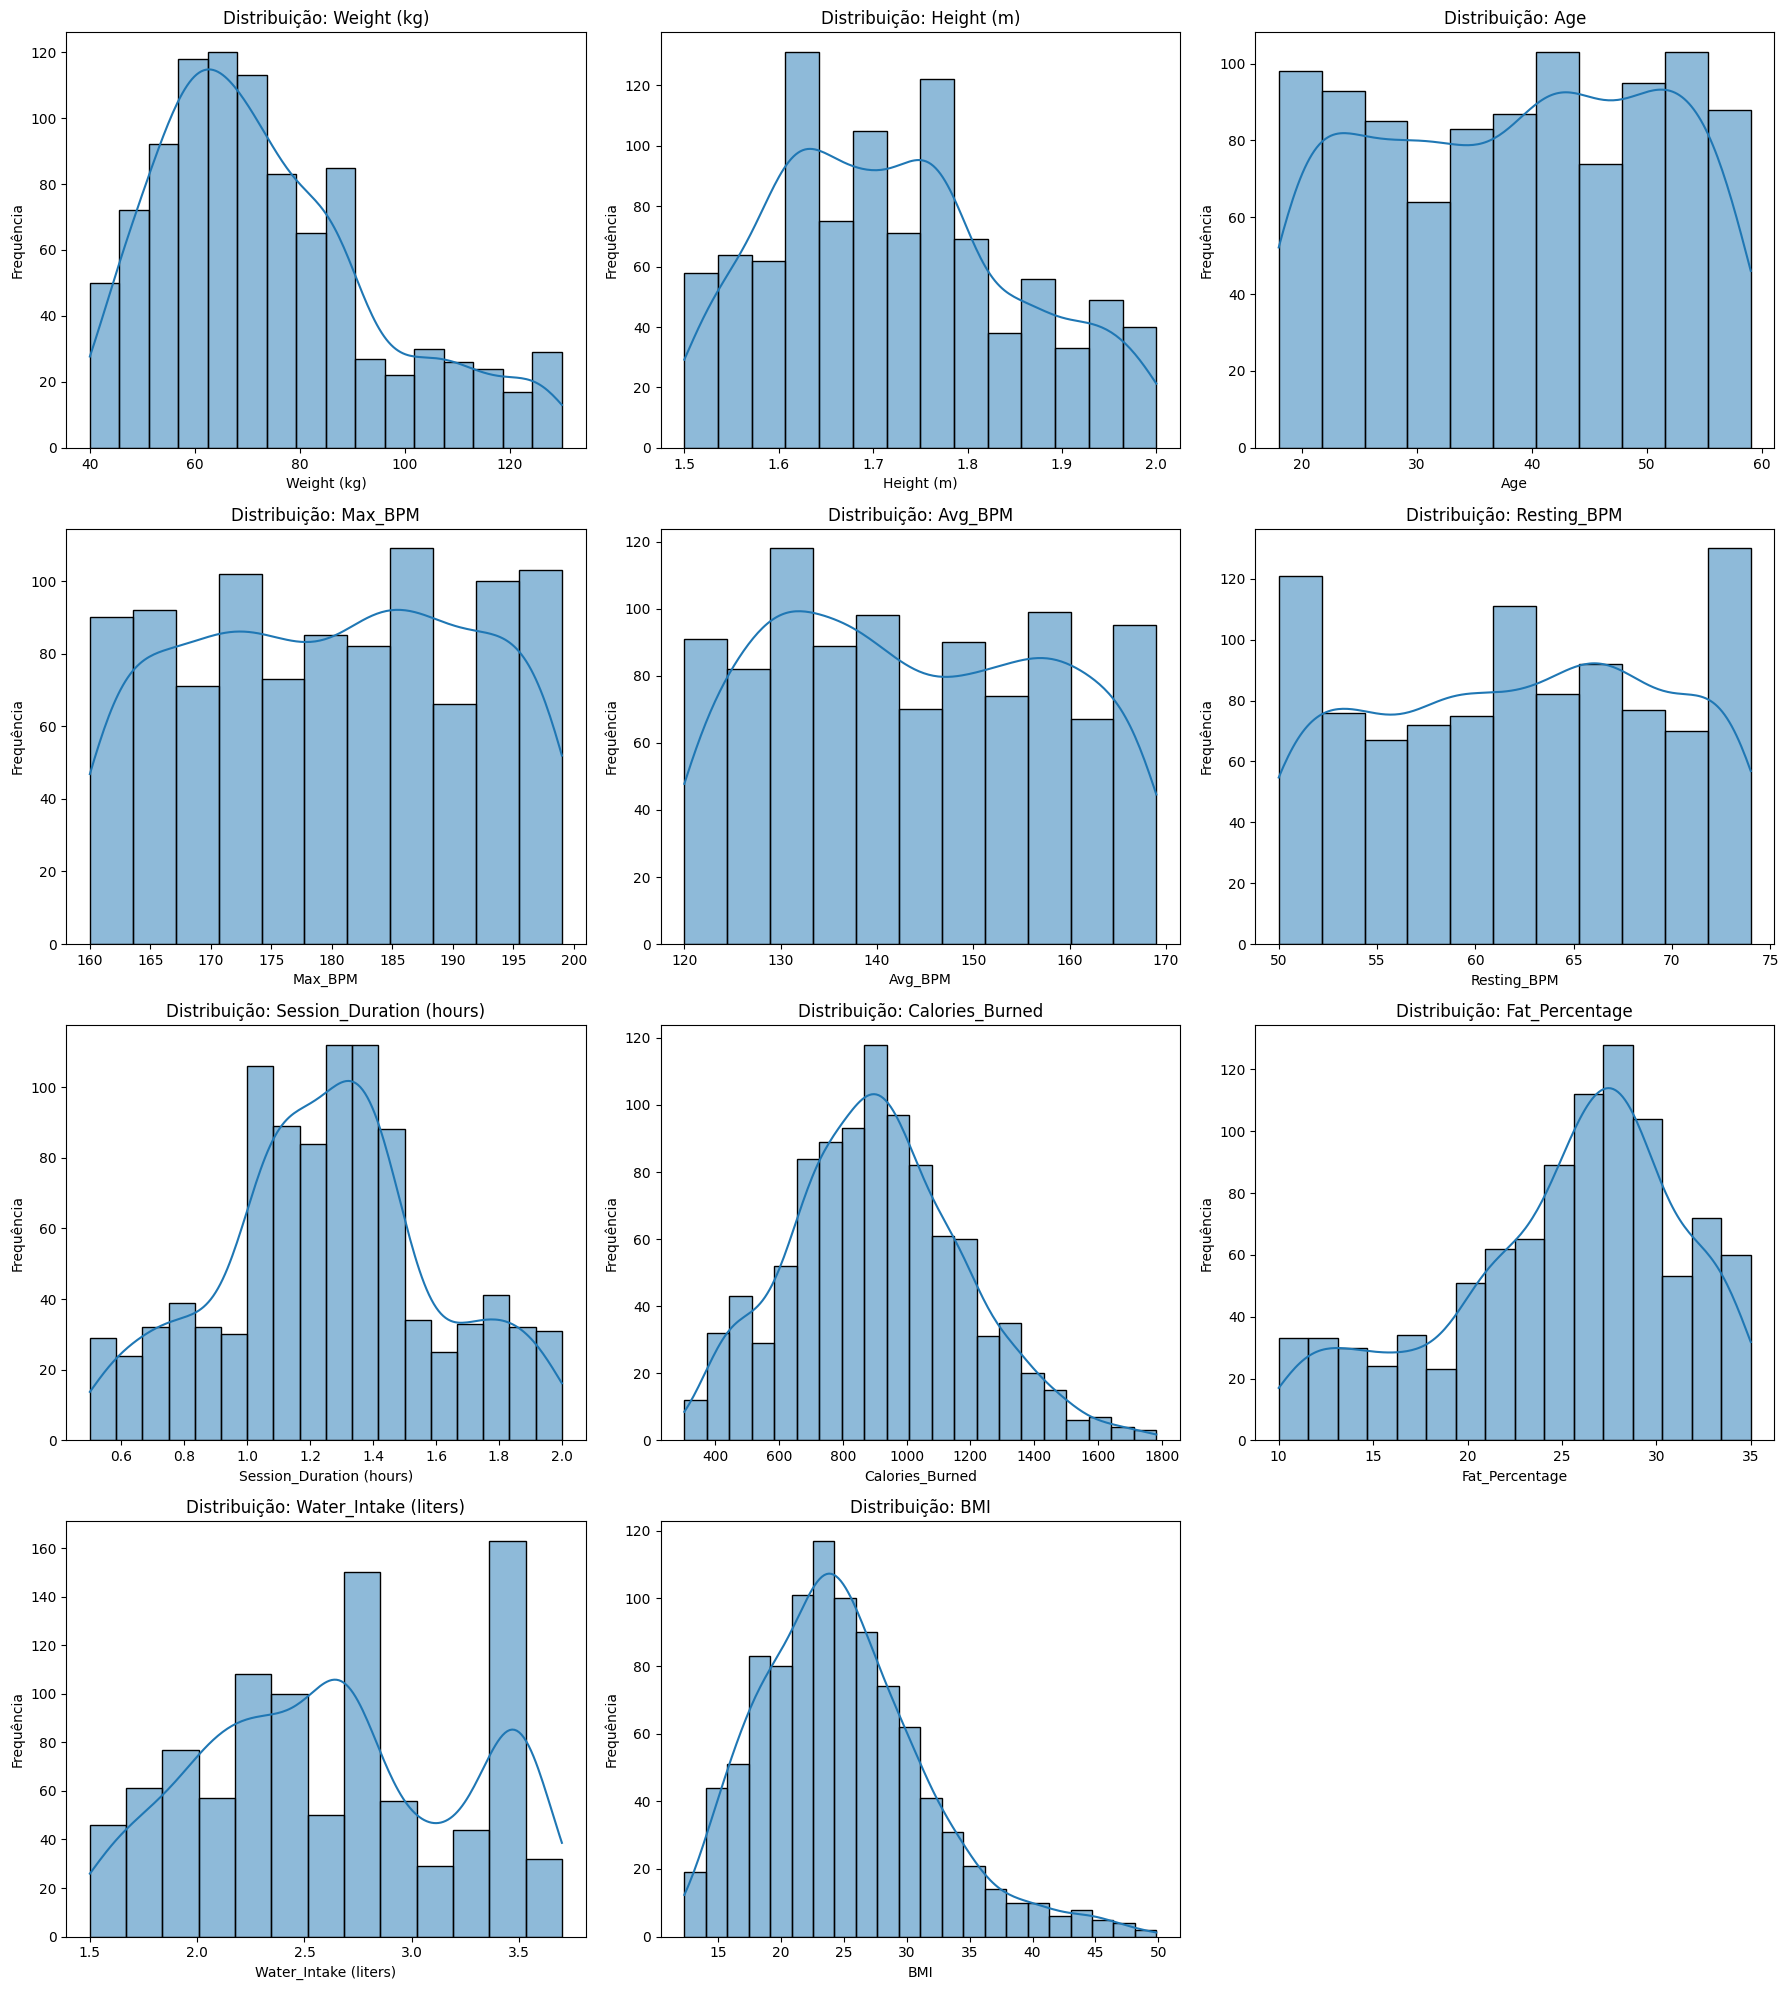

In [45]:
# Selecionando colunas que são tipicamente contínuas para histogramas
cols_continuas = ['Weight (kg)', 'Height (m)', 'Age', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
                  'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage',
                  'Water_Intake (liters)', 'BMI']

n_cols = 3
n_rows = math.ceil(len(cols_continuas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_continuas):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

# Remover eixos vazios se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Análise Bivariada

### Categóricas (não vistas na matriz)

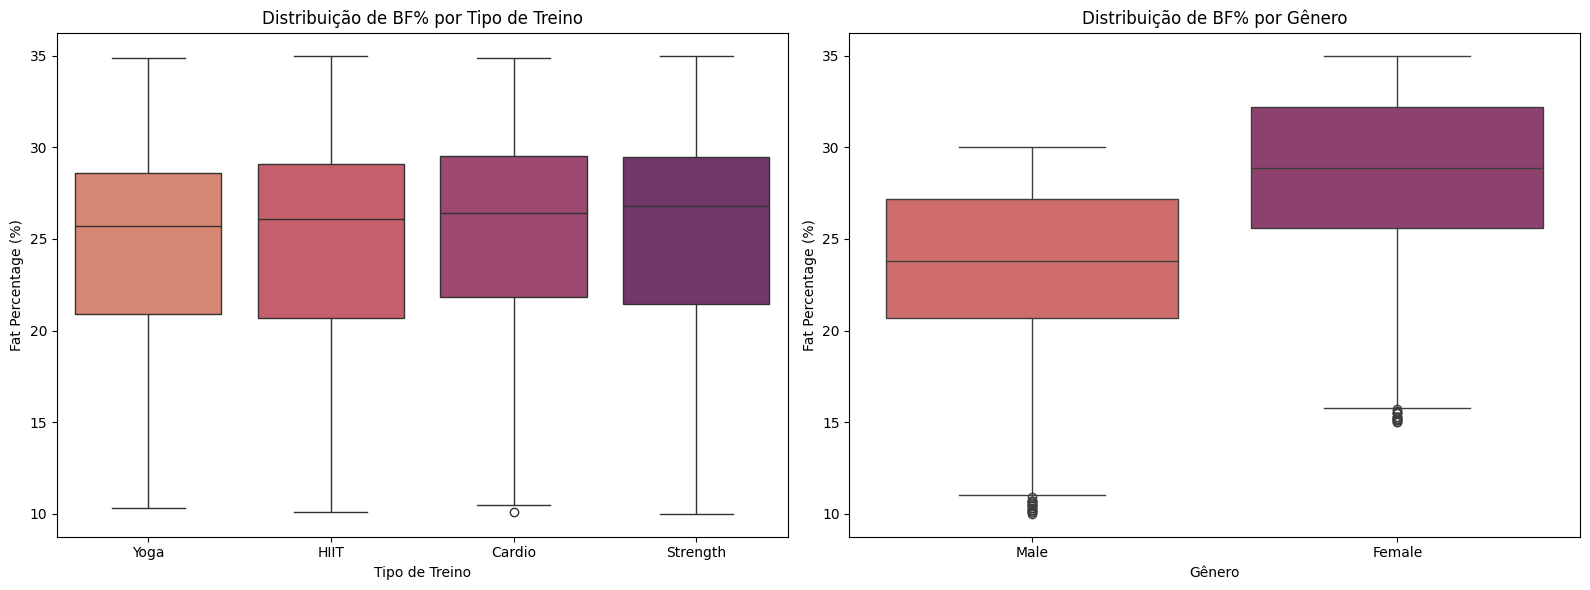

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot: Tipo de Treino vs BF%
sns.boxplot(x='Workout_Type', y='Fat_Percentage', data=df, ax=axes[0], palette='flare', hue='Workout_Type', legend=False)
axes[0].set_title('Distribuição de BF% por Tipo de Treino')
axes[0].set_xlabel('Tipo de Treino')
axes[0].set_ylabel('Fat Percentage (%)')

# 2. Boxplot: Gênero vs BF%
sns.boxplot(x='Gender', y='Fat_Percentage', data=df, ax=axes[1], palette='flare', hue='Gender', legend=False)
axes[1].set_title('Distribuição de BF% por Gênero')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Fat Percentage (%)')

plt.tight_layout()
plt.show()

### Focadas no BF

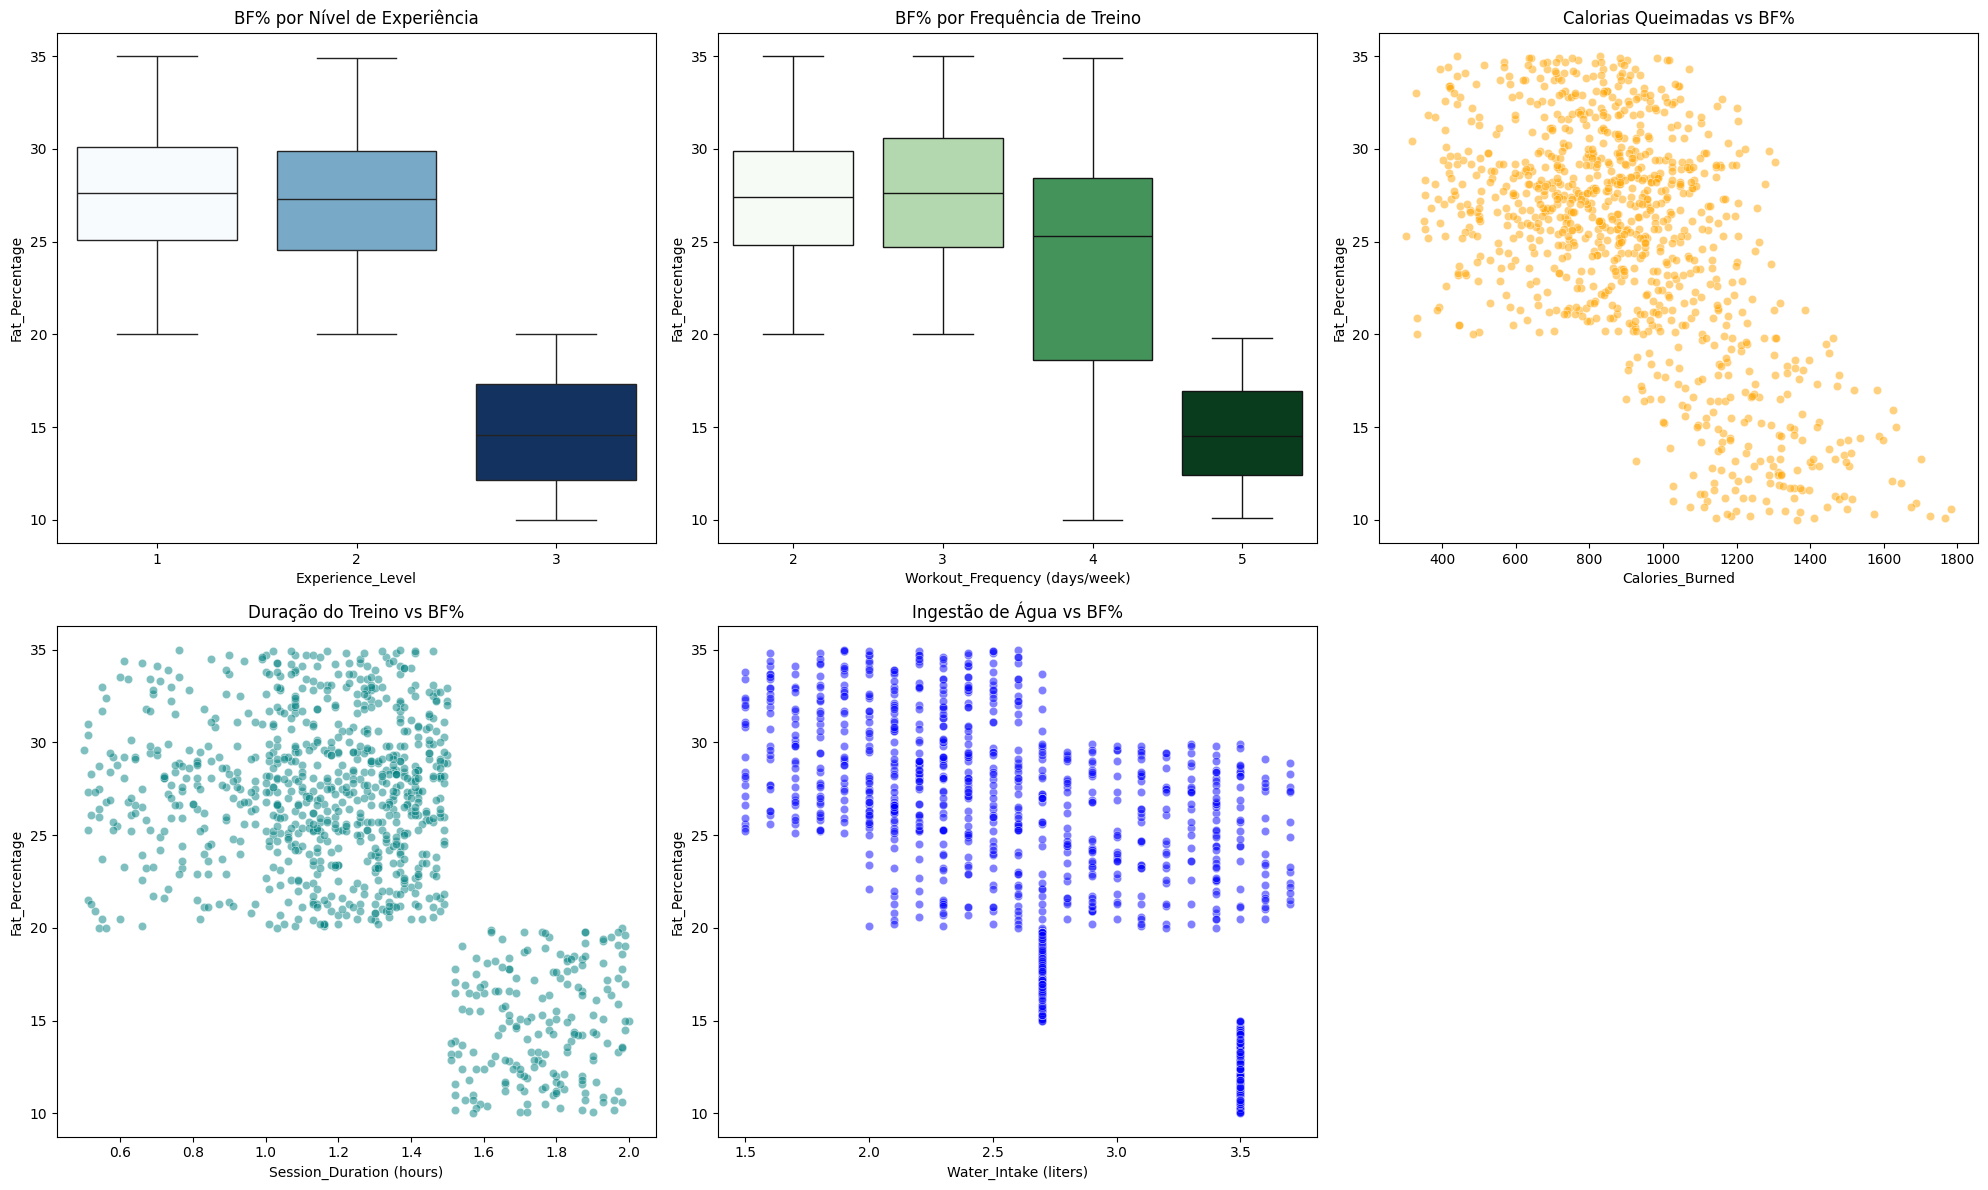

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Boxplot: Experiência vs BF
sns.boxplot(x='Experience_Level', y='Fat_Percentage', data=df, ax=axes[0, 0], palette='Blues', hue='Experience_Level', legend=False)
axes[0, 0].set_title('BF% por Nível de Experiência')

# 2. Boxplot: Frequência vs BF
sns.boxplot(x='Workout_Frequency (days/week)', y='Fat_Percentage', data=df, ax=axes[0, 1], palette='Greens', hue='Workout_Frequency (days/week)', legend=False)
axes[0, 1].set_title('BF% por Frequência de Treino')

# 3. Scatterplot: Calorias vs BF
sns.scatterplot(x='Calories_Burned', y='Fat_Percentage', data=df, ax=axes[0, 2], color='orange', alpha=0.5)
axes[0, 2].set_title('Calorias Queimadas vs BF%')

# 4. Scatterplot: Duração vs BF
sns.scatterplot(x='Session_Duration (hours)', y='Fat_Percentage', data=df, ax=axes[1, 0], color='teal', alpha=0.5)
axes[1, 0].set_title('Duração do Treino vs BF%')

# 5. Scatterplot: Água vs BF
sns.scatterplot(x='Water_Intake (liters)', y='Fat_Percentage', data=df, ax=axes[1, 1], color='blue', alpha=0.5)
axes[1, 1].set_title('Ingestão de Água vs BF%')

# Remover o último eixo vazio
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

### Correlação x Causalidade

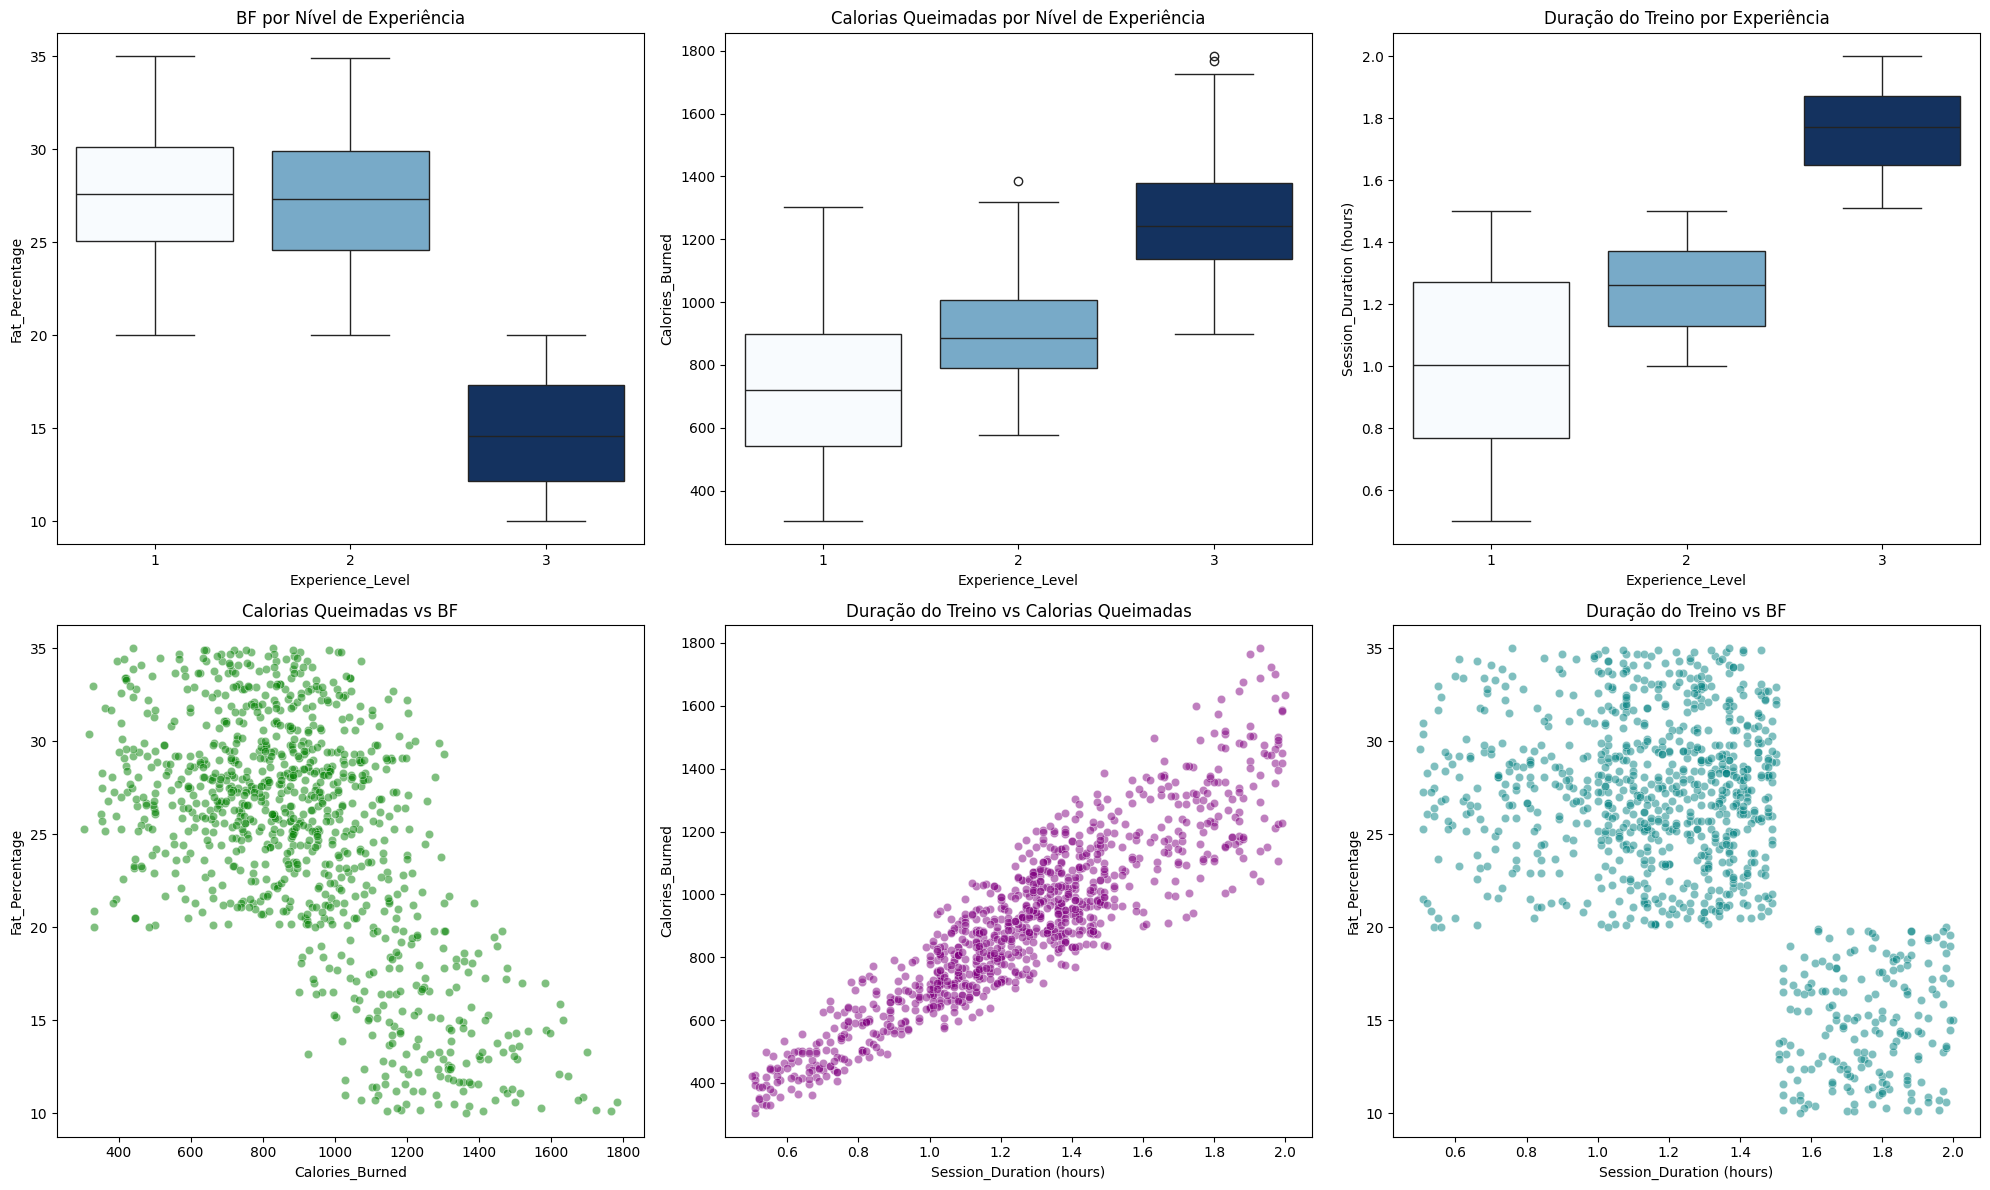

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# --- LINHA 1: BOXPLOTS ---
# 1. Experience vs BF
sns.boxplot(x='Experience_Level', y='Fat_Percentage', data=df, ax=axes[0, 0], palette='Blues', hue='Experience_Level', legend=False)
axes[0, 0].set_title('BF por Nível de Experiência')

# 2. Experience vs Calories
sns.boxplot(x='Experience_Level', y='Calories_Burned', data=df, ax=axes[0, 1], palette='Blues', hue='Experience_Level', legend=False)
axes[0, 1].set_title('Calorias Queimadas por Nível de Experiência')

# 3. Experience vs Duration
sns.boxplot(x='Experience_Level', y='Session_Duration (hours)', data=df, ax=axes[0, 2], palette='Blues', hue='Experience_Level', legend=False)
axes[0, 2].set_title('Duração do Treino por Experiência')

# --- LINHA 2: SCATTERPLOTS ---
# 4. Calories vs BF
sns.scatterplot(x='Calories_Burned', y='Fat_Percentage', data=df, ax=axes[1, 0], color='green', alpha=0.5)
axes[1, 0].set_title('Calorias Queimadas vs BF')

# 5. Duration vs Calories
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', data=df, ax=axes[1, 1], color='purple', alpha=0.5)
axes[1, 1].set_title('Duração do Treino vs Calorias Queimadas')

# 6. Duration vs BF
sns.scatterplot(x='Session_Duration (hours)', y='Fat_Percentage', data=df, ax=axes[1, 2], color='teal', alpha=0.5)
axes[1, 2].set_title('Duração do Treino vs BF')

plt.tight_layout()
plt.show()

Com esses gráficos, é possível visualizar e esclarecer uma possível confusão entre a relação de **Causalidade x Correlação** com o BF entre essas três variáveis:
- Nível de experiência
- Calorias queimadas
- Duração de Treino

O nível de experiência de um atleta não queima gordura de forma mágica. Os experientes têm um nível de BF menor por terem mais **gasto calórico** devido aos seus hábitos, como treinos mais longos, que implicam diretamente com as calorias que o atleta gasta e que por final é o que realmente causa uma diminuição no BF dos atletas por aumentar a chance de **déficit calórico**.

## Resumo

### Gênero

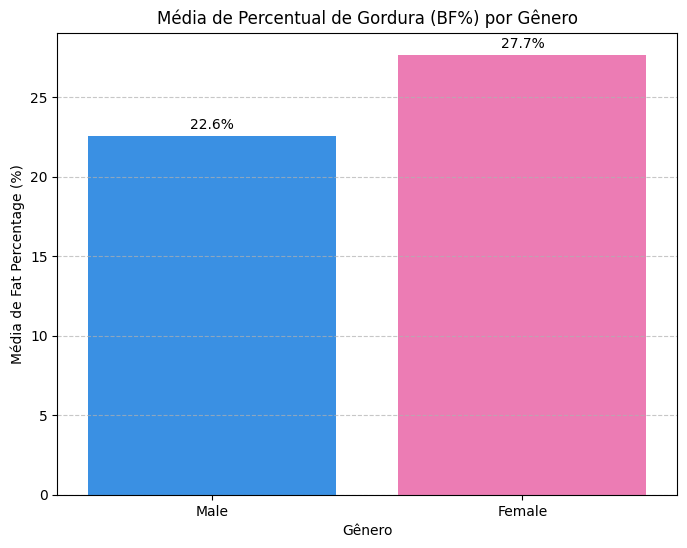

In [79]:
plt.figure(figsize=(8, 6))
# Definindo as cores específicas para cada gênero
cores_genero = {'Female': 'hotpink', 'Male': 'dodgerblue'}

ax = sns.barplot(x='Gender', y='Fat_Percentage', data=df, hue='Gender', palette=cores_genero, errorbar=None, legend=False)

# Adicionando rótulos com a média
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Média de Percentual de Gordura (BF%) por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Média de Fat Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

É possível observar uma **diferença de 5.1%** entre o BF das mulheres e dos homens. Isso se dá ao fator fisiológico entre os gêneros

### Nível de Experiência

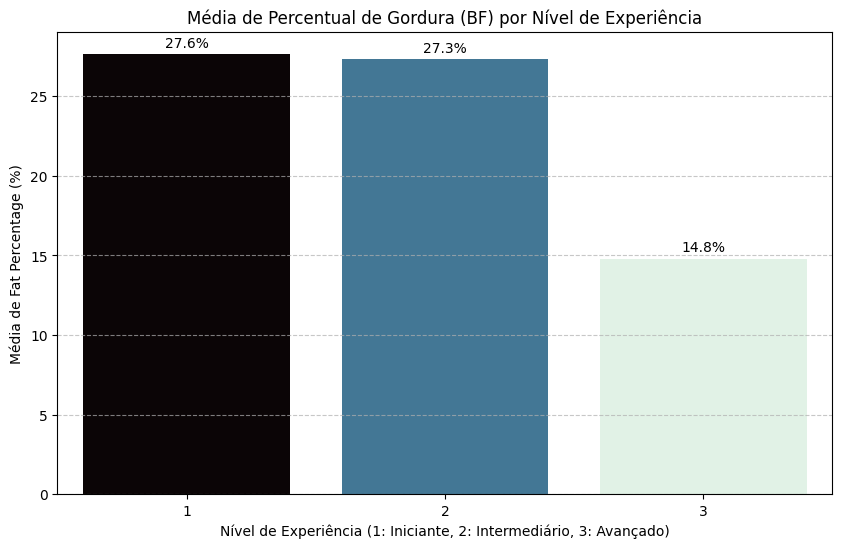

In [74]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Experience_Level', y='Fat_Percentage', data=df, hue='Experience_Level', palette='mako', errorbar=None, legend=False)

# Adicionando os rótulos de dados
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title('Média de Percentual de Gordura (BF) por Nível de Experiência')
plt.xlabel('Nível de Experiência (1: Iniciante, 2: Intermediário, 3: Avançado)')
plt.ylabel('Média de Fat Percentage (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

O gráfico deixa explícito uma **diferença de 12.5%** na média de BF entre níveis experientes e intermediários na academia.

### Hábitos de experientes

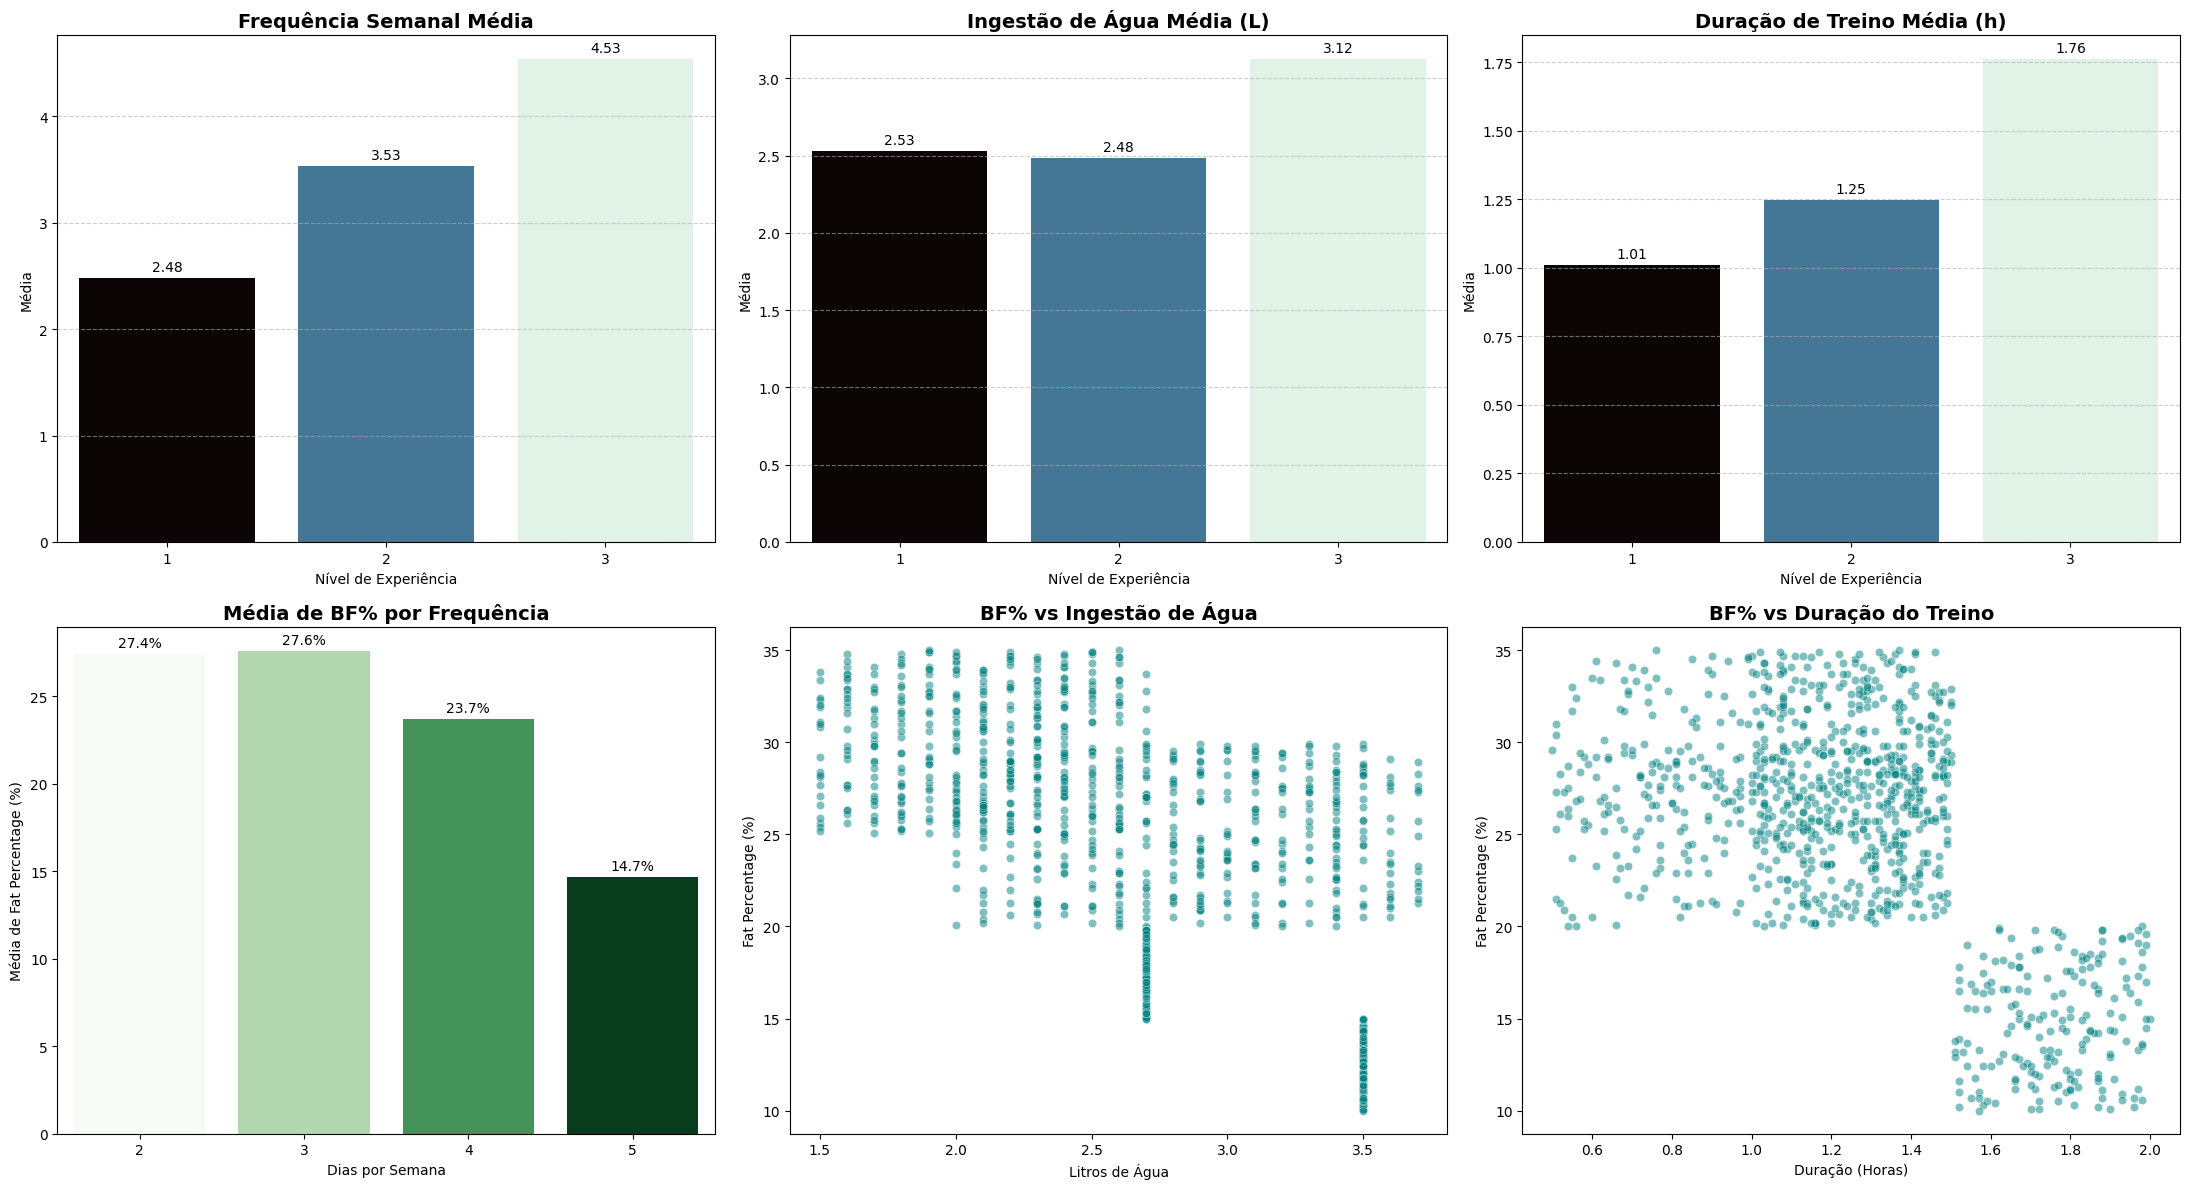

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# --- PRIMEIRA LINHA: MÉDIAS POR NÍVEL DE EXPERIÊNCIA ---
vars_to_plot = ['Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Session_Duration (hours)']
titles_top = ['Frequência Semanal Média', 'Ingestão de Água Média (L)', 'Duração de Treino Média (h)']

for i, var in enumerate(vars_to_plot):
    sns.barplot(x='Experience_Level', y=var, data=df, hue='Experience_Level', palette='mako', errorbar=None, legend=False, ax=axes[0, i])

    # Adicionando os rótulos de dados
    for container in axes[0, i].containers:
        axes[0, i].bar_label(container, fmt='%.2f', padding=3)

    axes[0, i].set_title(titles_top[i], fontsize=14, fontweight='bold')
    axes[0, i].set_xlabel('Nível de Experiência')
    axes[0, i].set_ylabel('Média')
    axes[0, i].grid(axis='y', linestyle='--', alpha=0.6)

# --- SEGUNDA LINHA: RELAÇÕES COM BF% ---
# 1. BF Médio vs Frequência (Alterado para Barplot conforme solicitado)
sns.barplot(x='Workout_Frequency (days/week)', y='Fat_Percentage', data=df, hue='Workout_Frequency (days/week)', ax=axes[1, 0], palette='Greens', errorbar=None, legend=False)
for container in axes[1, 0].containers:
    axes[1, 0].bar_label(container, fmt='%.1f%%', padding=3)
axes[1, 0].set_title('Média de BF% por Frequência', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Dias por Semana')
axes[1, 0].set_ylabel('Média de Fat Percentage (%)')

# 2. BF vs Ingestão de Água (Scatter)
sns.scatterplot(x='Water_Intake (liters)', y='Fat_Percentage', data=df, ax=axes[1, 1], color='teal', alpha=0.5)
axes[1, 1].set_title('BF% vs Ingestão de Água', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Litros de Água')
axes[1, 1].set_ylabel('Fat Percentage (%)')

# 3. BF vs Duração do Treino (Scatter)
sns.scatterplot(x='Session_Duration (hours)', y='Fat_Percentage', data=df, ax=axes[1, 2], color='teal', alpha=0.5)
axes[1, 2].set_title('BF% vs Duração do Treino', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Duração (Horas)')
axes[1, 2].set_ylabel('Fat Percentage (%)')

plt.tight_layout()
plt.show()

Com esses gráficos é possível observar a grande diferença em níveis de BF em pessoas que têm hábitos de um experiente. Percebe-se também que todos os hábitos que vimos ter uma forte correlação negativa com o BF, fazem parte dos hábitos de um atleta experiente.

## Conclusão

Após uma investigação profunda e estruturada nesta base de dados de atletas de academia, conseguimos mapear com precisão o ecossistema de variáveis que se relacionam com o **Percentual de Gordura (`Fat_Percentage`)**.

### 1. Resumo dos Achados Estatísticos
Os dados empíricos nos mostraram que as reduções mais expressivas de BF não acontecem de forma isolada, mas estão fortemente correlacionadas a um grupo de variáveis de comportamento e consistência:
* **Gasto Energético (`Calories_Burned` = -0.60):** O principal fator físico associado linearmente à queda do BF.
* **Maturidade Esportiva (`Experience_Level` = -0.65):** Atletas experientes (Nível 3) registram, em média, **12.5% a menos de BF** do que indivíduos intermediários.
* **Volume de Treino e Hidratação:** A duração da sessão (**-0.58**) e o consumo de água (**-0.59**) completam o bloco de maior relevância estatística.
* **O Fator Gênero (`Gender`):** A análise de médias revelou uma separação biológica clara na distribuição dos dados, onde o público masculino apresenta, em média, **5.1% a menos de BF** do que o público feminino, refletindo as características hormonais e de composição corporal naturais de cada gênero.

Em contrapartida, variáveis como **Idade (0.00)** e os batimentos cardíacos de treino (**`Avg_BPM` e `Max_BPM` a -0.01**) provaram ter associação linear **nula** com a composição corporal final nesta população.

### 2. A Visão Causal e Biológica
A maior riqueza desta EDA foi decifrar o mecanismo causal oculto pelas correlações. Isoladamente, "beber água" ou "acumular anos de academia" não queimam gordura. Contudo, nossa análise bivariada cruzada provou que o **Nível de Experiência** funciona como uma variável indicadora de um estilo de vida modificado:
1. Atletas experientes conseguem sustentar e preferem sessões de treino mais longas.
2. Treinos mais longos e intensos geram um gasto calórico massivamente superior.
3. Para sustentar esse nível de atividade e performance metabólica, esses indivíduos consomem muito mais água.

Portanto, o fator biológico que causa a redução do BF é o **déficit calórico acumulado** suportado por constância e hábitos de saúde do atleta, operando sobre as linhas de base fisiológicas de cada gênero

In [83]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [82]:
!mv "/content/Cópia de gym_athletes_data_analysis.ipynb" /content/fitness-data-insights/gym_athletes_data_analysis.ipynb

mv: cannot stat '/content/Cópia de gym_athletes_data_analysis.ipynb': No such file or directory
